In [2]:
import re
import glob
import matplotlib.pyplot as plt

BASE_DIR = "/home/anthony/cs285-rl/hw2"

In [3]:
def read_wandb_history(run_dir, metrics=("Train_AverageReturn",)):
    """Read Train_EnvstepsSoFar and specified metrics from the output.log file."""
    log_files = glob.glob(f"{BASE_DIR}/{run_dir}/wandb/run-*/files/output.log")
    if not log_files:
        raise FileNotFoundError(f"No output.log found in {run_dir}")

    with open(log_files[0]) as f:
        text = f.read()

    results = {m: [] for m in metrics}
    results["steps"] = []
    for block in text.split("Iteration ")[1:]:
        m_steps = re.search(r"Train_EnvstepsSoFar : (-?[\d.]+)", block)
        if not m_steps:
            continue
        metric_vals = {}
        for m in metrics:
            match = re.search(rf"{re.escape(m)} : (-?[\d.]+)", block)
            if match:
                metric_vals[m] = float(match.group(1))
        if len(metric_vals) == len(metrics):
            results["steps"].append(int(float(m_steps.group(1))))
            for m in metrics:
                results[m].append(metric_vals[m])

    return results

In [4]:
# Map experiment names to their directories (from experiment-explanation.md)
small_batch_experiments = {
    "cartpole":        "experiments/tmpppx4f5as",
    "cartpole_rtg":    "experiments/tmp5ph868xb",
    "cartpole_na":     "experiments/tmpv330eysd",
    "cartpole_rtg_na": "experiments/tmpvn030yav",
}

large_batch_experiments = {
    "cartpole_lb":        "experiments/tmpe4yjh6yg",
    "cartpole_lb_rtg":    "experiments/tmpe683v6_9",
    "cartpole_lb_na":     "experiments/tmp_vafnug2",
    "cartpole_lb_rtg_na": "experiments/tmp3gxvylyv",
}

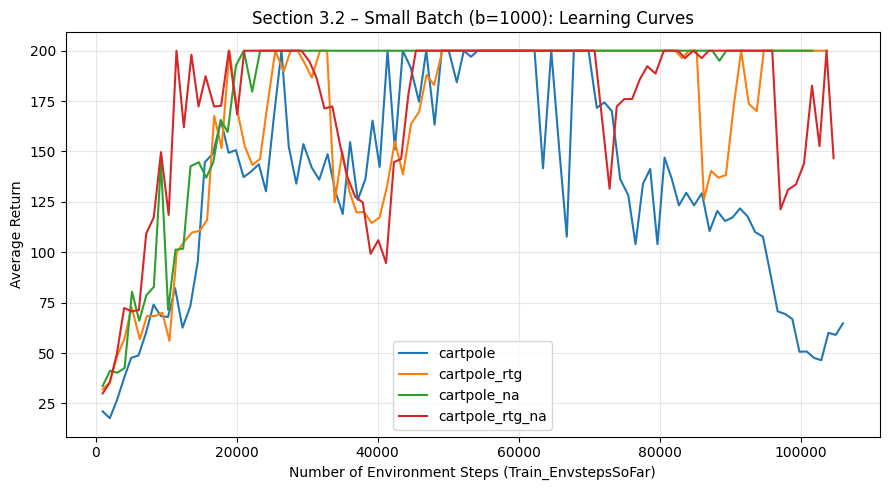

In [5]:
fig, ax = plt.subplots(figsize=(9, 5))

for name, path in small_batch_experiments.items():
    data = read_wandb_history(path, metrics=("Eval_AverageReturn",))
    ax.plot(data["steps"], data["Eval_AverageReturn"], label=name)

ax.set_xlabel("Number of Environment Steps (Train_EnvstepsSoFar)")
ax.set_ylabel("Average Return")
ax.set_title("Section 3.2 – Small Batch (b=1000): Learning Curves")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

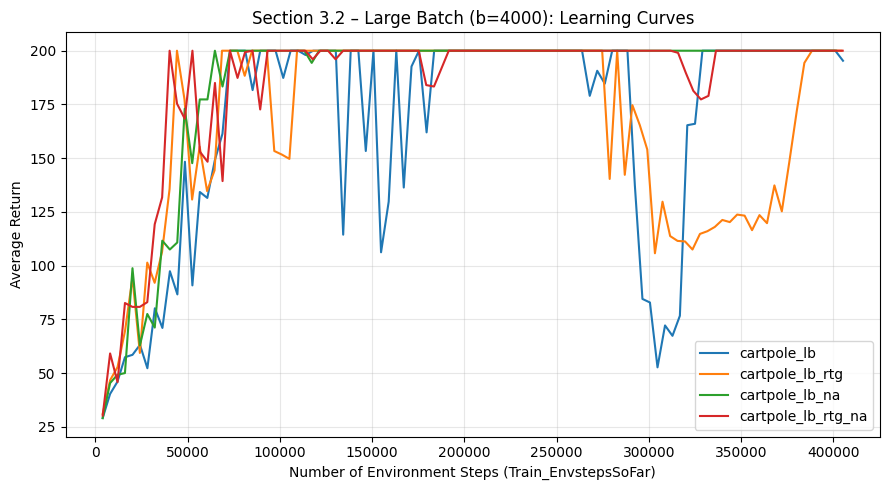

In [6]:
fig, ax = plt.subplots(figsize=(9, 5))

for name, path in large_batch_experiments.items():
    data = read_wandb_history(path, metrics=("Eval_AverageReturn",))
    ax.plot(data["steps"], data["Eval_AverageReturn"], label=name)

ax.set_xlabel("Number of Environment Steps (Train_EnvstepsSoFar)")
ax.set_ylabel("Average Return")
ax.set_title("Section 3.2 – Large Batch (b=4000): Learning Curves")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [7]:
# Section 4.2 experiments
cheetah_experiments = {
    "cheetah (no baseline)": "experiments/tmprrtsvgqx",
    "cheetah_baseline":      "experiments/tmpkegkt8hw",
}

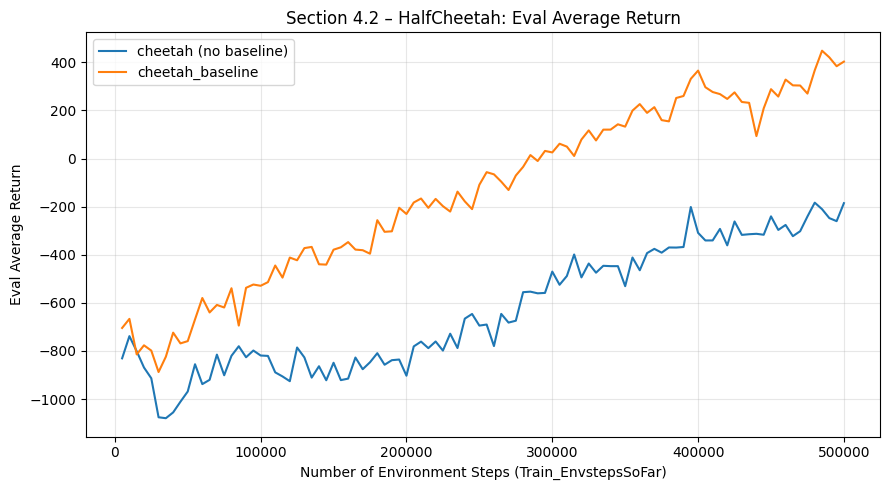

In [8]:
fig, ax = plt.subplots(figsize=(9, 5))

for name, path in cheetah_experiments.items():
    data = read_wandb_history(path, metrics=("Eval_AverageReturn",))
    ax.plot(data["steps"], data["Eval_AverageReturn"], label=name)

ax.set_xlabel("Number of Environment Steps (Train_EnvstepsSoFar)")
ax.set_ylabel("Eval Average Return")
ax.set_title("Section 4.2 – HalfCheetah: Eval Average Return")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

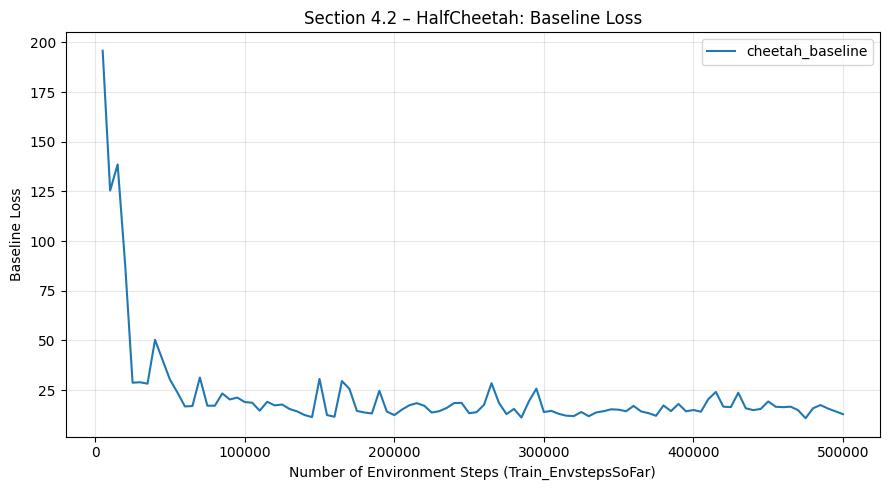

In [9]:
fig, ax = plt.subplots(figsize=(9, 5))

# Only the baseline experiment has Baseline Loss
data = read_wandb_history("experiments/tmpkegkt8hw", metrics=("Baseline Loss",))
ax.plot(data["steps"], data["Baseline Loss"], label="cheetah_baseline")

ax.set_xlabel("Number of Environment Steps (Train_EnvstepsSoFar)")
ax.set_ylabel("Baseline Loss")
ax.set_title("Section 4.2 – HalfCheetah: Baseline Loss")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

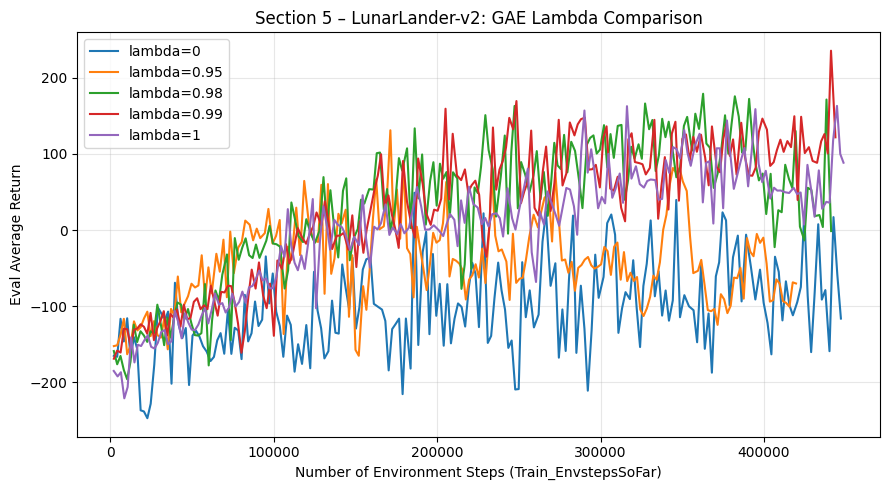

In [10]:
# Section 5 experiments
lunar_lander_experiments = {
    "lambda=0":    "experiments/tmpvvhr2y5p",
    "lambda=0.95": "experiments/tmprsqrngda",
    "lambda=0.98": "experiments/tmpgpdk7oya",
    "lambda=0.99": "experiments/tmp_r8j7bx4",
    "lambda=1":    "experiments/tmp02cvjdae",
}

fig, ax = plt.subplots(figsize=(9, 5))

for name, path in lunar_lander_experiments.items():
    data = read_wandb_history(path, metrics=("Eval_AverageReturn",))
    ax.plot(data["steps"], data["Eval_AverageReturn"], label=name)

ax.set_xlabel("Number of Environment Steps (Train_EnvstepsSoFar)")
ax.set_ylabel("Eval Average Return")
ax.set_title("Section 5 – LunarLander-v2: GAE Lambda Comparison")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# Section 6 experiments
pendulum_experiments = {
    "pendulum_default (b=5000)": "experiments/tmpj2y7c231",
    "pendulum_tuned1 (b=1000)":  "experiments/tmpyc20rit1",
}

fig, ax = plt.subplots(figsize=(9, 5))

for name, path in pendulum_experiments.items():
    data = read_wandb_history(path, metrics=("Eval_AverageReturn",))
    ax.plot(data["steps"], data["Eval_AverageReturn"], label=name)

ax.set_xlabel("Number of Environment Steps (Train_EnvstepsSoFar)")
ax.set_ylabel("Eval Average Return")
ax.set_title("Section 6 – InvertedPendulum: Hyperparameters & Sample Efficiency")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()